# DBSCAN and HDBSCAN

### Clusters defined by density, not by distance to a centre

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | How density-based clustering finds shapes k-means cannot, how to choose `eps` from the data instead of guessing, why it labels points as noise, and where it fails |
| **You should already know** | [k-Means](../01-k-means/) |
| **Datasets** | UCI Dry Bean, plus synthetic shapes chosen to separate the two methods |
| **Runtime** | About a minute on a laptop CPU |
| **Next** | [05-05 Gaussian Mixture Models](../05-gaussian-mixture-models/) |

---

## 1. The idea

[k-means](../01-k-means/) ended on two failures: it cannot find crescents, and it
happily carves pure noise into tidy wedges. Both come from the same source: it
defines a cluster as *points near a centre*, and it must assign every point to one.

DBSCAN defines a cluster differently: **a dense region, of any shape, separated
from other dense regions by sparse space.** It works from two parameters:

- `eps`: how far away counts as "nearby"
- `min_samples`: how many neighbours within `eps` make a point *core*

Every point is then one of three things. A **core point** has at least
`min_samples` neighbours within `eps`. A **border point** is within `eps` of a
core point but is not core itself. Everything else is **noise**.

Clusters grow by chaining core points together. That chaining is why a crescent
works: no point needs to be near a centre, only near its neighbours.

Two consequences fall out immediately. **You do not specify the number of
clusters**: it emerges. And **not every point gets assigned**, which is the
feature k-means most conspicuously lacks.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

## 2. Head to head on the shapes that broke k-means

          shape  k-means k  DBSCAN clusters  noise share
    round blobs          3                1     0.067143
  two crescents          2                2     0.000000
stretched blobs          3                1     0.027143
  uniform noise          3                2     0.000000

uniform noise, as eps tightens:
  eps=0.30:  2 clusters,  0.0% called noise
  eps=0.20: 16 clusters,  9.3% called noise
  eps=0.15: 19 clusters, 71.7% called noise
  eps=0.10:  0 clusters, 100.0% called noise
  eps=0.07:  0 clusters, 100.0% called noise


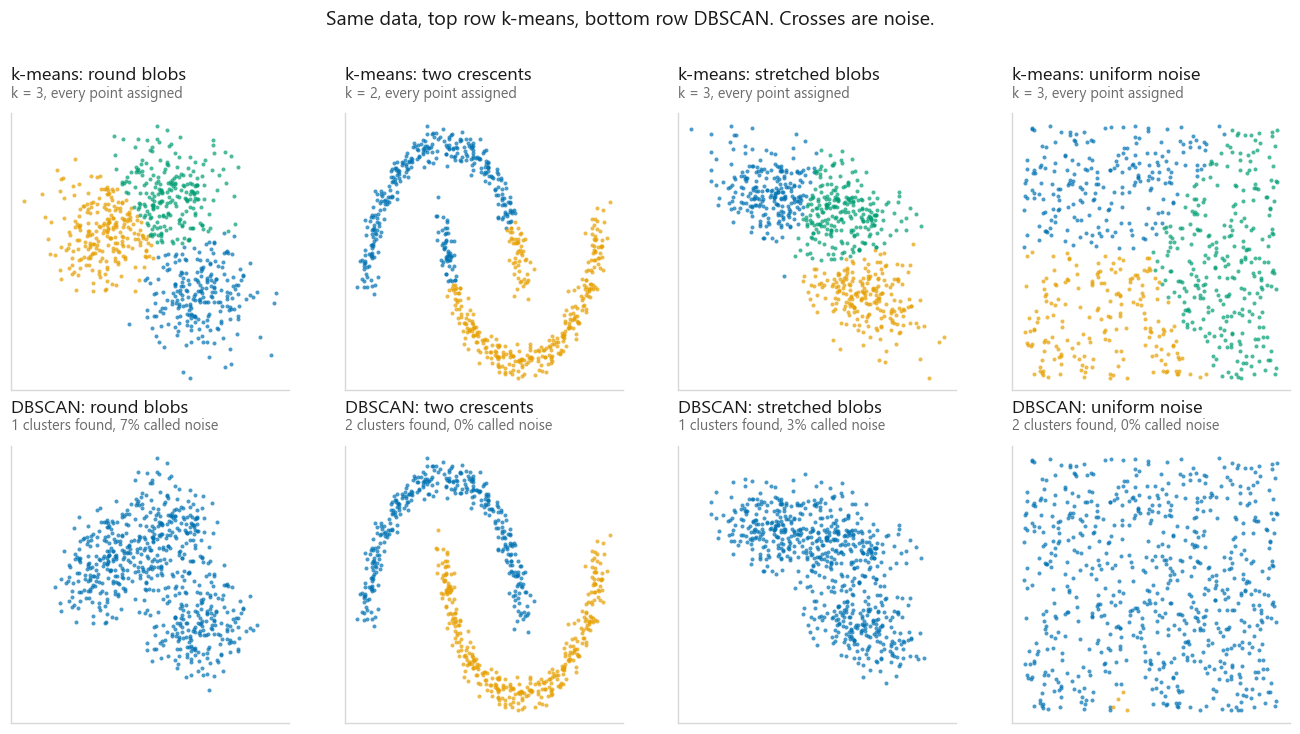

In [2]:
from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(SEED)
shapes = {
    "round blobs": (make_blobs(n_samples=700, centers=3, cluster_std=1.0, random_state=SEED)[0], 3, 0.30),
    "two crescents": (make_moons(n_samples=700, noise=0.06, random_state=SEED)[0], 2, 0.30),
    "stretched blobs": (make_blobs(n_samples=700, centers=3, random_state=SEED)[0] @ [[0.7, -0.7], [0.1, 0.9]], 3, 0.35),
    "uniform noise": (rng.uniform(-3, 3, size=(700, 2)), 3, 0.30),
}


def draw(ax, points, labels, title, subtitle=None):
    noise = labels == -1
    for i, c in enumerate(sorted(set(labels[~noise]))):
        sel = labels == c
        ax.scatter(points[sel, 0], points[sel, 1], s=7, alpha=0.7,
                   c=style.PALETTE[i % len(style.PALETTE)], linewidths=0)
    if noise.any():
        ax.scatter(points[noise, 0], points[noise, 1], s=7, alpha=0.45,
                   c=style.RULE, linewidths=0, marker="x")
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    style.title(ax, title, subtitle)


fig, axes = plt.subplots(2, 4, figsize=(15.0, 7.2))
summary = []

for col, (name, (points, k, eps)) in enumerate(shapes.items()):
    scaled = StandardScaler().fit_transform(points)

    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(scaled)
    draw(axes[0, col], points, km.labels_, f"k-means: {name}", f"k = {k}, every point assigned")

    db = DBSCAN(eps=eps, min_samples=8).fit(scaled)
    found = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    noise_share = (db.labels_ == -1).mean()
    draw(axes[1, col], points, db.labels_, f"DBSCAN: {name}",
         f"{found} clusters found, {noise_share:.0%} called noise")
    summary.append({"shape": name, "k-means k": k, "DBSCAN clusters": found,
                    "noise share": noise_share})

fig.suptitle("Same data, top row k-means, bottom row DBSCAN. Crosses are noise.",
             x=0.5, y=1.01, fontsize=13, color=style.INK)
style.save(fig, FIG / "fig-01-shapes.png")

print(pd.DataFrame(summary).to_string(index=False))

# Does a tighter eps let DBSCAN reject the structureless data?
print("\nuniform noise, as eps tightens:")
uniform = StandardScaler().fit_transform(shapes["uniform noise"][0])
for eps in [0.30, 0.20, 0.15, 0.10, 0.07]:
    labels = DBSCAN(eps=eps, min_samples=8).fit_predict(uniform)
    found = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"  eps={eps:.2f}: {found:>2} clusters, {(labels == -1).mean():>5.1%} called noise")

Read the bottom row against the top.

**Two crescents** is the headline. DBSCAN recovers both, because it never asks
whether a point is near a centre, only whether it is near another point in the
same dense region.

**Uniform noise** did not go the way I expected, and the correction is the most
useful thing in this notebook. I assumed DBSCAN would label most of the uniform
points as noise and effectively report "nothing here". It did not: at this `eps`
it found **two clusters and called nothing noise at all**.

The reason is obvious in hindsight. Uniform random points are *evenly* dense, not
sparse. Every point has plenty of neighbours within `eps`, so every point is a
core point, and the chaining runs through the whole square. DBSCAN has no concept
of "this density is meaninglessly low", only of density *relative to `eps`*.

The `eps` sweep printed above is the part worth keeping. Tightening `eps` does
eventually dissolve the cloud into noise, but there is **no setting at which
DBSCAN reports "this data has no structure"**. It goes from 2 spurious clusters,
to 16, to 19, and then straight to rejecting every single point. The useful
middle answer never appears.

So DBSCAN **can** emit a noise label, which k-means structurally cannot, and that
is a genuine advantage on data with real clusters plus outliers. It is not a free
safeguard against clustering structureless data. Deciding whether clusters exist
at all remains your job, exactly as it was with
[k-means](../01-k-means/).

**Stretched blobs** is where DBSCAN struggles too, and honestly. When elongated
groups nearly touch, the chaining runs straight from one into the next and merges
them.

## 3. Choosing eps without guessing

`eps` is the parameter that matters, and picking it by trial and error is how
most people meet DBSCAN. There is a better way: plot the distance from every
point to its `k`-th nearest neighbour, sorted. The elbow marks where points stop
being in dense regions.

suggested eps from the elbow: 1.848


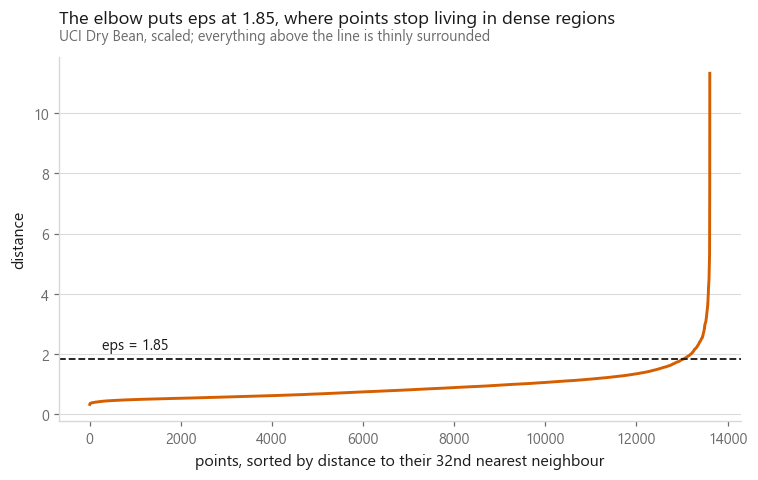

In [3]:
from sklearn.neighbors import NearestNeighbors

X_bean, y_bean = datasets.dry_bean()
X_scaled = StandardScaler().fit_transform(X_bean)

MIN_SAMPLES = 32
distances, _ = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_scaled).kneighbors(X_scaled)
kth = np.sort(distances[:, -1])

# The elbow: the point furthest from the straight line joining the two ends.
x0, y0, x1, y1 = 0, kth[0], len(kth) - 1, kth[-1]
line_distance = np.abs((y1 - y0) * np.arange(len(kth)) - (x1 - x0) * kth + x1 * y0 - y1 * x0)
elbow = int(np.argmax(line_distance))
eps_choice = float(kth[elbow])

fig, ax = plt.subplots(figsize=(8.0, 4.3))
ax.plot(kth, color=style.HIGHLIGHT)
ax.axhline(eps_choice, color=style.INK, ls="--", lw=1.2)
ax.annotate(f"eps = {eps_choice:.2f}", xy=(0, eps_choice), xytext=(8, 6),
            textcoords="offset points", fontsize=9.5, color=style.INK)
ax.set_xlabel("points, sorted by distance to their 32nd nearest neighbour")
ax.set_ylabel("distance")
style.title(ax, f"The elbow puts eps at {eps_choice:.2f}, where points stop living in dense regions",
            "UCI Dry Bean, scaled; everything above the line is thinly surrounded")
style.save(fig, FIG / "fig-02-choosing-eps.png")

print(f"suggested eps from the elbow: {eps_choice:.3f}")

## 4. On real data

Dry Bean has seven varieties. k-means recovered them at an adjusted Rand index of
0.669. DBSCAN gets the same test.

 eps  clusters found  noise share  adjusted Rand
0.50               3        0.737          0.046
0.80               4        0.323          0.273
1.85               2        0.013          0.033
1.40               2        0.038          0.036
1.80               2        0.015          0.033
2.20               1        0.007          0.001

k-means with k=7: adjusted Rand 0.669


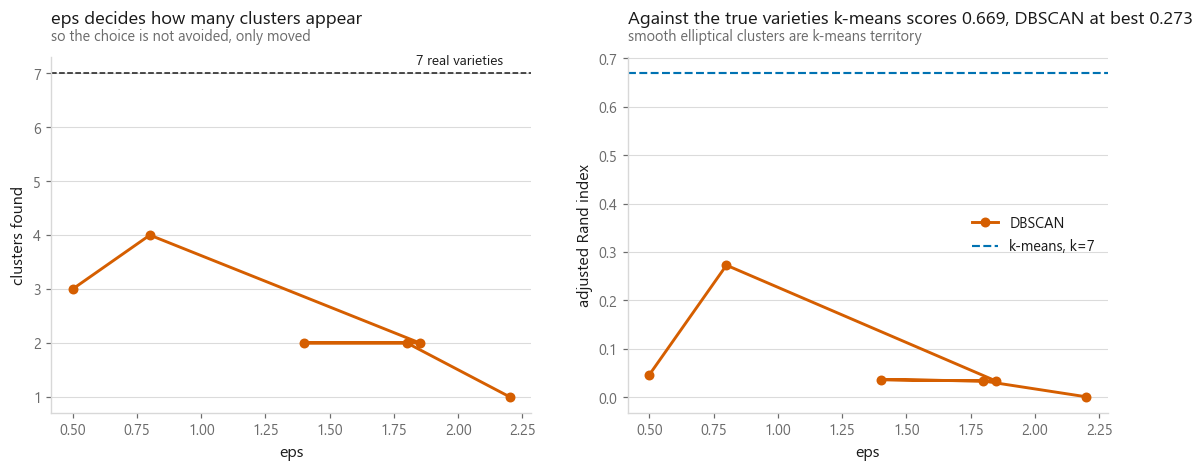

In [4]:
from sklearn.metrics import adjusted_rand_score

records = []
for eps in [0.5, 0.8, eps_choice, 1.4, 1.8, 2.2]:
    labels = DBSCAN(eps=eps, min_samples=MIN_SAMPLES, n_jobs=-1).fit_predict(X_scaled)
    found = len(set(labels)) - (1 if -1 in labels else 0)
    records.append({
        "eps": round(eps, 2),
        "clusters found": found,
        "noise share": (labels == -1).mean(),
        "adjusted Rand": adjusted_rand_score(y_bean, labels),
    })
sweep = pd.DataFrame(records)

kmeans_labels = KMeans(n_clusters=7, n_init=10, random_state=SEED).fit_predict(X_scaled)
kmeans_ari = adjusted_rand_score(y_bean, kmeans_labels)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.2))

axes[0].plot(sweep["eps"], sweep["clusters found"], marker=style.MARKERS[0], color=style.HIGHLIGHT)
axes[0].axhline(7, color=style.INK, ls="--", lw=1)
axes[0].annotate("7 real varieties", xy=(sweep["eps"].iloc[-1], 7), xytext=(-4, 6),
                 textcoords="offset points", ha="right", fontsize=9, color=style.INK)
axes[0].set_xlabel("eps"); axes[0].set_ylabel("clusters found")
style.title(axes[0], "eps decides how many clusters appear", "so the choice is not avoided, only moved")

axes[1].plot(sweep["eps"], sweep["adjusted Rand"], marker=style.MARKERS[0],
             color=style.HIGHLIGHT, label="DBSCAN")
axes[1].axhline(kmeans_ari, color=style.PALETTE[0], ls="--", lw=1.4, label="k-means, k=7")
axes[1].set_xlabel("eps"); axes[1].set_ylabel("adjusted Rand index")
axes[1].legend()
style.title(axes[1], f"Against the true varieties k-means scores {kmeans_ari:.3f}, DBSCAN at best {sweep['adjusted Rand'].max():.3f}",
            "smooth elliptical clusters are k-means territory")

style.save(fig, FIG / "fig-03-on-real-data.png")

print(sweep.round(3).to_string(index=False))
print(f"\nk-means with k=7: adjusted Rand {kmeans_ari:.3f}")

**DBSCAN loses on this dataset**, and the reason is instructive rather than
disappointing. Bean varieties form smooth, roughly elliptical, overlapping
clouds of similar density, the exact situation k-means was designed for. There
is no sparse space between varieties for DBSCAN to cut along, so it either merges
everything into one giant cluster or starts discarding large fractions as noise.

It also exposes the honest limitation: **`eps` decides how many clusters you
get.** DBSCAN does not remove the "how many clusters" decision, it renames it.
What it genuinely adds is arbitrary shapes and the ability to say "noise".

### HDBSCAN

HDBSCAN removes `eps` by running DBSCAN at every scale at once and keeping the
clusters that persist longest. It handles clusters of differing density, which
plain DBSCAN cannot, and needs only `min_cluster_size`.

In [5]:
try:
    from sklearn.cluster import HDBSCAN
    available = True
except ImportError:
    available = False

if available:
    for size in [50, 150, 400]:
        labels = HDBSCAN(min_cluster_size=size).fit_predict(X_scaled)
        found = len(set(labels)) - (1 if -1 in labels else 0)
        print(f"min_cluster_size={size:>4}: {found} clusters, "
              f"{(labels == -1).mean():.1%} noise, "
              f"adjusted Rand {adjusted_rand_score(y_bean, labels):.3f}")
else:
    print("HDBSCAN needs scikit-learn 1.3 or newer")

C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


min_cluster_size=  50: 2 clusters, 3.1% noise, adjusted Rand 0.035


C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


min_cluster_size= 150: 2 clusters, 4.7% noise, adjusted Rand 0.036


C:\Users\pilot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


min_cluster_size= 400: 2 clusters, 86.1% noise, adjusted Rand -0.003


## Cheat sheet

| | |
|---|---|
| **Use it when** | Clusters are irregular shapes; outliers exist and should stay out; you genuinely do not know how many clusters there are |
| **Avoid it when** | Clusters have very different densities (use HDBSCAN); the data is high-dimensional, where every point looks equally far away; groups are smooth and overlapping |
| **Scaling needed** | Yes. `eps` is a distance |
| **Main dials** | `eps` and `min_samples`. A rule of thumb is `min_samples` ≈ twice the number of dimensions |
| **Choosing eps** | The sorted k-distance elbow, as above. Not trial and error |
| **Watch out** | `eps` still controls the cluster count. And label `-1` means noise, not a cluster. Never treat it as one |

## What to remember

1. Density, not distance to a centre, is the definition. That is why a crescent
   works and why an elongated pair that nearly touches gets merged: both follow
   from clusters growing by chaining core points together.
2. It does not need the cluster count, and `eps` decides it anyway. The choice
   was renamed, not removed.
3. Pick `eps` from the sorted k-distance elbow rather than by trial and error.
   Trial and error means tuning a cluster count you told yourself you were not
   choosing.
4. It **can** say "no cluster here", which k-means structurally cannot, but that
   is not a safeguard. At a loose `eps` it split pure uniform noise into two
   groups and flagged nothing, because uniform points are evenly dense rather
   than sparse. Deciding whether clusters exist at all is still your job.
5. On smooth overlapping elliptical data, k-means beats it by a wide margin.
   Match the method to the shape, and if you cannot describe the shape, plot it
   before you cluster it.

Where to go next, depending on what you wanted from this chapter.

If the noise label was the point and the clusters were incidental,
[05-06 Anomaly detection](../06-anomaly-detection/) does that job properly and
hands back a ranked score instead of a yes or no.

If your data looks like the beans, smooth overlapping groups,
[05-05 Gaussian mixture models](../05-gaussian-mixture-models/) is the method for
it. That chapter also gives every point a likelihood rather than a hard label.

And if your data has many columns, be warned that `eps` gets harder to set the
more columns you add, because in high dimensions every point looks equally far
from every other one. [Part 6](../../06-dimensionality-reduction/) is about
getting the column count down.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [05-05 Gaussian Mixture Models](../05-gaussian-mixture-models/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#DBSCAN` `#HDBSCAN` `#Clustering` `#UnsupervisedLearning`
`#Python` `#ScikitLearn` `#DataScience` `#MLTutorial` `#AnomalyDetection`